# Warp Regression: An Introduction

I keep running into time series that have a recognisable *shape*: a cycle, a seasonal bump, a boom-and-bust pattern, but where the **timing** of that shape drifts around from one occurrence to the next. A business cycle that's usually four years but sometimes six. A ten-year boom-bust cycle that peaks two years early one decade and two years late the next.

The usual toolbox doesn't love this. ARIMA and seasonal decomposition assume the phase is fixed, or close to it. Flexible smoothers (splines, GPs, tree ensembles) can fit almost anything, but they treat the mistiming as unstructured noise. You lose the "it's basically the same shape, just early or late" story, which is usually the *interesting* part.

So here's something in between: **warp regression**. The idea is simple to state and a little fiddly to implement well, so this notebook walks through the mechanics on a small synthetic example before we point it at real data (lynx trappings and Bitcoin) in the next two notebooks.

## The core idea

Assume there's a known-shape **cycle** (a sine wave is the simplest case), and what we actually observe is a **warped** version of it, passed through some **output function**:

$$\hat y_i = f\big(\mathrm{warp}(c,\, p)_i\big)$$

Two moving parts:

- $f$ is the **output function**: it maps the cycle onto your actual target. Could be linear ($A \cdot c + C$), could be an MLP, could be a trend-plus-sine composition.
- $p$ is the **warp path**: a sequence of *fractional* indices into the cycle. If $p(i) = i$ for every $i$, there's no warp at all. Wherever $p$ drifts away from that identity line, the cycle effectively speeds up or slows down.

`warp(c, p)` just means "read the cycle at a non-integer index, linearly interpolating between the two nearest samples". That's what makes the whole thing differentiable: no discrete alignment step, no DTW-style search, just a warp path you can push gradients through.

## Why not just use dynamic time warping?

DTW is the obvious existing answer to "align a sequence with time-shifted structure". It's a great algorithm, but it's fundamentally an **optimisation** tool, not a **generative** one. You get a single best alignment and no natural way to:

1. regularise the warp (there's no built-in trade-off knob between fit and plausibility),
2. get an actual uncertainty distribution over *future* timing,
3. jointly learn the cycle, the output function, and the warp under one objective.

Warp regression fixes this by putting a **likelihood** on the warp path itself, right alongside the usual likelihood on the observations.

## The dual loss

Training balances two terms, controlled by a mixing weight `fit_lambda` ($\lambda$):

| Term | What it measures |
|------|----------------|
| **error** (`obj_err`) | Gaussian negative log-likelihood of the residuals: the usual "how well does $\hat y$ match $y$" |
| **terror** (`obj_time`) | *Timing* error: a random-walk log-likelihood on the warp offsets $p(i) - i$. Penalises jagged, implausible warps |

(Yes, *terror* = **t**iming **error**. Deliberately silly name for a genuinely useful term: it's the piece that keeps the warp path smooth instead of overfitting to noise.)

$$\texttt{loss} = \lambda \cdot \texttt{error} \;-\; (1-\lambda) \cdot \texttt{terror}$$

Push $\lambda$ toward 1 and the model chases fit, risking an overfit warp. Push it toward 0 and it leans on the smoothness prior, risking underfit timing shifts. In practice something in $[0.5, 0.9]$ works well, depending on how much data you have and how flexible the output function is.

## Where the uncertainty bands come from

Because the warp path has a likelihood attached, you can literally **sample** plausible future warp paths: continue the random walk forward from the last training point, and push each sample through the output function. That gives you a distribution of forecasts, not just a point estimate:

- **terror band**: spread across future warp-path forecasts (timing uncertainty alone).
- **combined band**: terror plus observation noise, drawn jointly (`paths_terror + N(0, σ_y²)`), which is the honest way to stack two independent sources of uncertainty.

That's the pitch. Let's see it work.


In [1]:

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch

from warp_regression import (
    NOTEBOOK_LL_TARGET,
    WarpParametricModel,
    applied_path_offset_numpy,
    build_forecast_bands,
    build_synthetic_dataset,
    evaluate_model,
    per_index_rw_sigma,
    plot_dual_objective_scatter,
    plot_forecast_bands,
    plot_realisation_spaghetti,
    predict_forecast_realisations_torch,
    predict_realisations_torch,
    soft_warp_numpy,
    split_synthetic_holdout,
    stored_path_offset_numpy,
)


## Step 1: cook up some synthetic data

Before touching real data, let's build a toy problem where we *know* the ground truth: a sine cycle, run through a hidden random-walk warp path, plus a bit of Gaussian noise on top. That way we can check whether the model recovers something close to the true warp, not just something that fits the observations.

`build_synthetic_dataset()` does exactly this (it mirrors the original prototype notebook, `WarpPureNumpy.ipynb`, so the numbers below match a known reference). We'll hold out the last 100 points to mimic the same train/test structure we'll use on Lynx and Bitcoin.


n=300  sr=10  scale=10.0  noise_std=0.2
Train indices 0-199 (n=200)  |  Test indices 200-299 (n=100)


/Users/ap/Desktop/warp/warp_regression/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


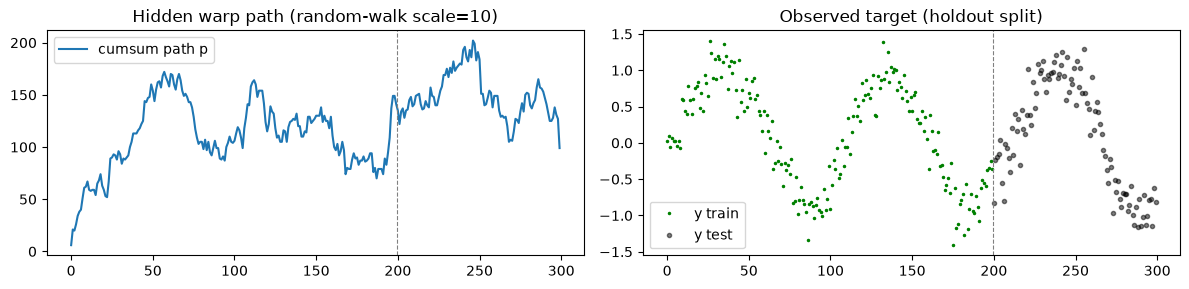

In [2]:
data = build_synthetic_dataset()
print(f"n={data['n']}  sr={data['sr']}  scale={data['scale']}  noise_std={data['noise_std']}")

split = split_synthetic_holdout(data["n"], n_train=200)
train_idx, test_idx = split["train_idx"], split["test_idx"]
n_train, n_test = split["n_train"], split["n_test"]
print(f"Train indices 0-{n_train - 1} (n={n_train})  |  Test indices {n_train}-{data['n'] - 1} (n={n_test})")

y_train = torch.tensor(data["y"][train_idx], dtype=torch.float32)
sr = data["sr"]

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(data["p_true"], label="cumsum path p")
axes[0].axvline(n_train - 0.5, color="gray", ls="--", lw=0.8)
axes[0].set_title("Hidden warp path (random-walk scale=10)")
axes[0].legend()
axes[1].plot(train_idx, data["y"][train_idx], "g.", ms=3, label="y train")
axes[1].plot(test_idx, data["y"][test_idx], "ko", ms=3, alpha=0.5, label="y test")
axes[1].axvline(n_train - 0.5, color="gray", ls="--", lw=0.8)
axes[1].set_title("Observed target (holdout split)")
axes[1].legend()
fig.tight_layout()
plt.show()


## Step 2: get a rough sine wave in place first

We don't hand the model a perfect cycle to warp; we let it discover a reasonable starting point itself. `prefit(y, t, n_sines=1)` grid-searches phase (and frequency, if not already fixed) to line up a sine wave with `y_train` on calendar time. This is exactly the same API we'll use for Lynx and Bitcoin later.

The fitted cycle `z` becomes the thing that gets warped in step 3: $\hat y = A \cdot \mathrm{warp}(z, p) + C$.


In [3]:
from warp_regression import prefit

t_tr = (train_idx + 1).astype(np.float64) / 100.0  # calendar scale of sin(2*pi*t)
t_full = (np.arange(data["n"]) + 1).astype(np.float64) / 100.0
prefit_res = prefit(y_train.numpy(), t_tr, n_sines=1, t_full=t_full)
sine_fit = prefit_res.sine_fit
x_train = torch.tensor(prefit_res.drivers["z"], dtype=torch.float32)
print(
    f"Prefit n_sines=1  omega={sine_fit['omega']:.3f}  phase={sine_fit['phase']:.3f}  "
    f"corr={sine_fit['presize_corr']:.3f}"
)


Prefit n_sines=1  omega=1.000  phase=5.585  corr=0.940


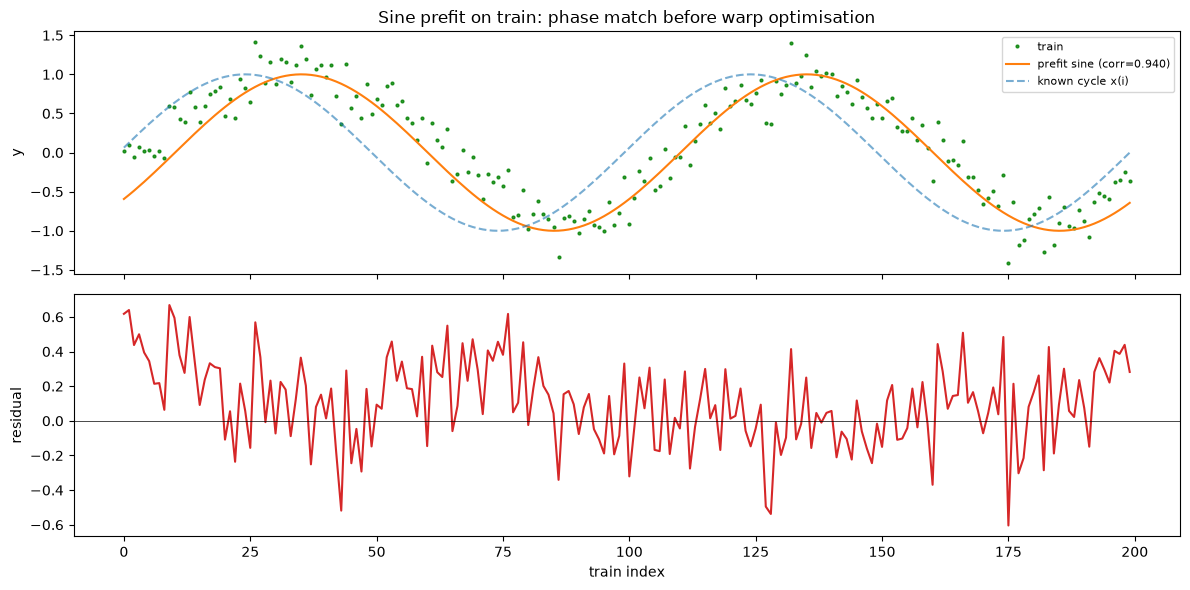

In [4]:
from warp_regression import plot_fit_with_residual

z_pre = sine_fit["z"]
y_np = y_train.numpy()
x_raw = data["x"][:n_train]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
plot_fit_with_residual(
    axes, train_idx, y_np, z_pre,
    extra_lines=[(train_idx, x_raw, {"color": "C0", "ls": "--", "alpha": 0.6, "label": "known cycle x(i)"})],
    fit_label=f"prefit sine (corr={sine_fit['presize_corr']:.3f})",
    xlabel="train index",
    title="Sine prefit on train: phase match before warp optimisation",
)
plt.tight_layout()
plt.show()


## Step 3: train the warp path and output function together

Now for the actual model. `WarpParametricModel` stores the warp path as B-spline knot values, plus a learnable amplitude `A`, bias `C`, and two log-scales: $\sigma_t$ (how loose the warp is allowed to be) and $\sigma_y$ (observation noise). Everything trains jointly under the dual loss from `fit_lambda=0.5`, using the prefit cycle from step 2.

(There's a standalone script, `train_warp.py`, that trains the full-series reference checkpoint we compare against below.)


In [5]:
# ŷ = A·soft_warp(z_prefit, p) + C; knots in p learned jointly with A, C, σ_t, σ_y
from pathlib import Path
ckpt = Path("outputs") / "model.pt"
model = WarpParametricModel(n=n_train, n_knots=8, sr=sr, A_init=1.0, C_init=0.0)

model.fit(x_train, y_train, epochs=5000, lr=0.03, seed=0, fit_lambda=0.5)
ckpt.parent.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), ckpt)

with torch.no_grad():
    sigma_t = float(torch.exp(model.log_sigma_t))
    p_fit = model.path().numpy()
    off_apply = applied_path_offset_numpy(p_fit)
report = evaluate_model(model, x_train, y_train, use_discrete_warp=True, n=n_train, sr=sr)
print(f"sigma_t={sigma_t:.4f}  per_index_rw_sigma={per_index_rw_sigma(sigma_t, n_train, model.n_knots):.4f}")
print(f"offset_apply step std={np.std(np.diff(off_apply)):.4f}")
print(f"Train report: {report}")
print(f"Full-series LL reference (train_warp.py): {NOTEBOOK_LL_TARGET}")


sigma_t=0.1417  per_index_rw_sigma=0.7555
offset_apply step std=0.1127
Train report: EvalReport(mse=0.0432271845638752, rmse=0.20791148252050726, corr=0.9542670875256165, obj_err=-30.34086799621582, obj_time=0.007314043585211039, err_nll=30.34086799621582, time_ll=-0.007314043585211039, ll_distance=596.2273198791573, discrete_mse=0.06637242093536103)
Full-series LL reference (train_warp.py): (283.71669407633806, 506.8158229257141)


## Step 4: did it actually recover the warp?

This is the nice part about a synthetic example: we know the true warp path, so we can check the model's homework. Below: the fitted curve against the data, the learned path $p$ against the true cumulative-sum path, and the offsets $p(i) - i$ side by side.


Path anchor: end-pinned (offset[199]=0.00)
  learned p vs ground-truth stored path corr = 0.996
  prefit sine corr (step 2) = 0.940


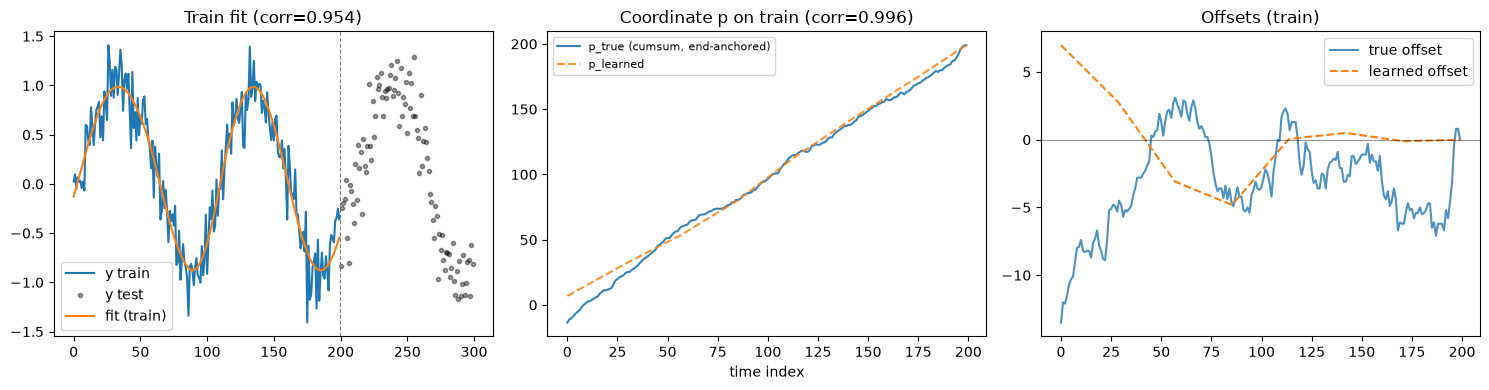

In [6]:
from warp_regression import DEFAULT_PATH_ANCHOR, cumsum_path_to_stored_path

with torch.no_grad():
    d = model.losses(x_train, y_train, torch.tensor(0.5))
    y_fit = d["y_hat"].numpy()
    p_fit = d["p"].numpy()

p_true_stored = cumsum_path_to_stored_path(
    data["p_true"], n_train, sr, path_anchor=DEFAULT_PATH_ANCHOR
)

off_fit = stored_path_offset_numpy(p_fit)
off_true = stored_path_offset_numpy(p_true_stored)
print(f"Path anchor: end-pinned (offset[{n_train - 1}]={off_fit[-1]:.2f})")
print(f"  learned p vs ground-truth stored path corr = {np.corrcoef(p_true_stored, p_fit)[0,1]:.3f}")
print(f"  prefit sine corr (step 2) = {sine_fit['presize_corr']:.3f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(train_idx, y_train.numpy(), label="y train")
ax[0].plot(test_idx, data["y"][test_idx], "ko", ms=3, alpha=0.4, label="y test")
ax[0].plot(y_fit, label="fit (train)")
ax[0].axvline(n_train - 0.5, color="gray", ls="--", lw=0.8)
ax[0].legend()
ax[0].set_title(f"Train fit (corr={report.corr:.3f})")

ax[1].plot(p_true_stored, label="p_true (cumsum, end-anchored)", alpha=0.9)
ax[1].plot(p_fit, linestyle="--", label="p_learned", alpha=0.85)
ax[1].legend(fontsize=8)
ax[1].set_title(f"Coordinate p on train (corr={np.corrcoef(p_true_stored, p_fit)[0,1]:.3f})")
ax[1].set_xlabel("time index")

ax[2].plot(off_true, label="true offset", alpha=0.8)
ax[2].plot(off_fit, linestyle="--", label="learned offset")
ax[2].axhline(0, color="k", linewidth=0.8, alpha=0.4)
ax[2].legend()
ax[2].set_title("Offsets (train)")
plt.tight_layout()
plt.show()


/var/folders/5s/p4grnv4s5k17kjk3xgp7qpmh0000gn/T/ipykernel_14305/1453179557.py:10: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:839.)
  sigma_t = float(torch.exp(model.log_sigma_t))


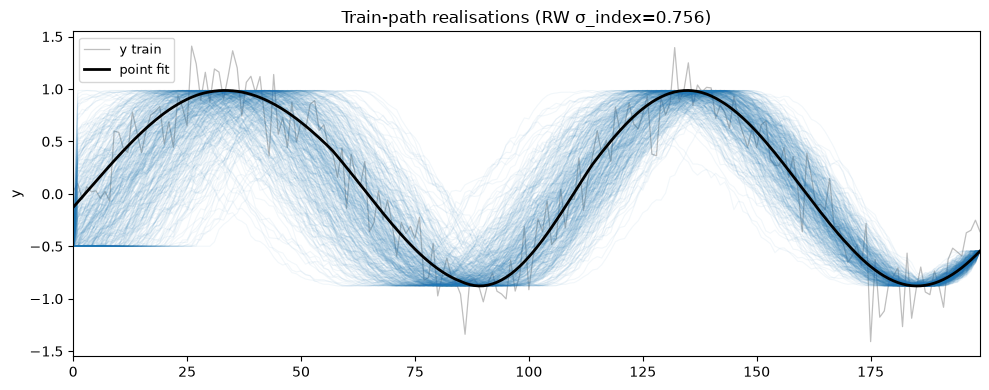

paths shape (400, 200)  std[0]=0.0000  std[199]=0.0000


In [7]:
# Sample RW continuations of the fitted path over the train window itself,
# to see how quickly timing uncertainty grows even before we touch the holdout.
h = n_train
n_draws = 400
paths = predict_realisations_torch(model, x_train, n_draws=n_draws, horizon=h)

with torch.no_grad():
    y_fit = model.predict(x_train).numpy()

sigma_t = float(torch.exp(model.log_sigma_t))
sigma_step = per_index_rw_sigma(sigma_t, n_train, model.n_knots)

fig, ax = plt.subplots(figsize=(10, 4))
plot_realisation_spaghetti(
    ax, np.arange(h), paths, np.arange(h), y_fit,
    x_obs=train_idx, y_obs=y_train.numpy(), obs_label="y train",
    point_label="point fit", path_alpha=0.06,
    title=f"Train-path realisations (RW σ_index={sigma_step:.3f})",
)
ax.set_xlim(0, h - 1)
fig.tight_layout()
plt.show()

print(f"paths shape {paths.shape}  std[0]={paths[:, 0].std():.4f}  std[{h-1}]={paths[:, -1].std():.4f}")


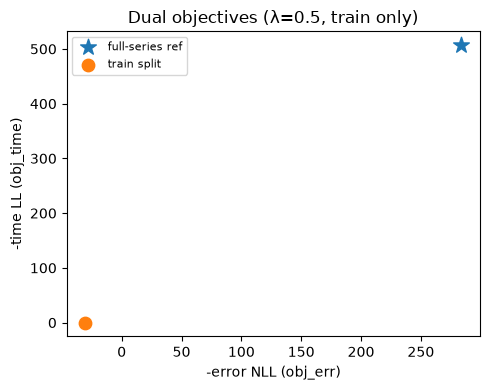

In [8]:
# Where do the two objectives land relative to the full-series reference fit?
fig, ax = plt.subplots(figsize=(5, 4))
plot_dual_objective_scatter(
    ax,
    [
        {"x": NOTEBOOK_LL_TARGET[0], "y": NOTEBOOK_LL_TARGET[1], "label": "full-series ref", "marker": "*", "s": 140},
        {"x": report.obj_err, "y": report.obj_time, "label": "train split", "s": 80},
    ],
    title="Dual objectives (λ=0.5, train only)",
)
plt.tight_layout()
plt.show()


## Step 5: forecast the holdout

Now the part that actually matters for forecasting: extend the warp path past the training window using the same random-walk step size ($\sigma_{\text{index}} = \sigma_t \sqrt{\Delta}$, per index), run each sampled path through the output function, and look at the spread.

`build_forecast_bands` turns those samples into two bands: a **terror** band (percentiles of the path forecasts) and a **combined** band (percentiles of `paths_terror + N(0, σ_y²)`, drawn jointly). The **point forecast** just freezes the offset at the last training index and reads the cycle forward: no randomness, the deterministic baseline.


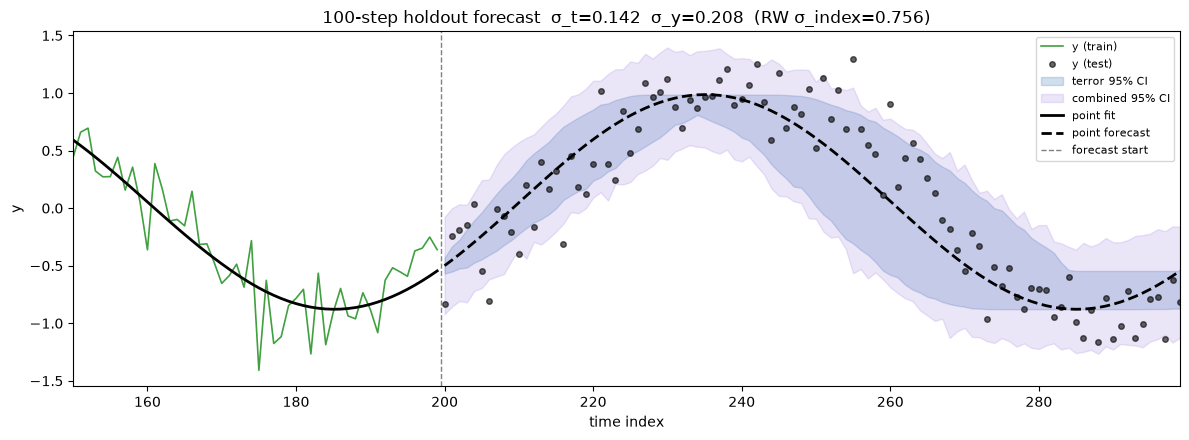

test corr (point) = 0.916
test RMSE = 0.3028
test in combined 95% band: 93%
combined band width at test start/end: 0.8456 / 0.9651


In [9]:
n_future = n_test
n_context = 50
n_draws_ci = 400

fc = predict_forecast_realisations_torch(
    model, x_train, n_future=n_future, n_draws=n_draws_ci, seed=1, sine_fit=sine_fit
)
bands = fc["bands"]
n_total = fc["n_total"]
sigma_y = fc["sigma_y"]
sigma_t = fc["sigma_t"]
y_point = fc["y_point"]
y_test = data["y"][test_idx]

plot_start = max(0, n_train - n_context)
t_idx_train = np.arange(plot_start, n_train)
bands_test = {k: bands[k][test_idx] for k in ("t_q_lo", "t_q_hi", "c_q_lo", "c_q_hi")}

fig, ax = plt.subplots(figsize=(12, 4.5))
plot_forecast_bands(
    ax, t_idx_train, data["y"][plot_start:n_train], test_idx, bands_test,
    x_test=test_idx, y_test=y_test,
    point_lines=[
        (t_idx_train, y_point[plot_start:n_train], {"color": "black", "lw": 2, "label": "point fit"}),
        (test_idx, y_point[test_idx], {"color": "black", "lw": 2, "ls": "--", "label": "point forecast"}),
    ],
    forecast_start_x=n_train - 0.5,
    train_label="y (train)", test_label="y (test)",
    xlabel="time index",
    title=(
        f"{n_future}-step holdout forecast  σ_t={sigma_t:.3f}  σ_y={sigma_y:.3f}  "
        f"(RW σ_index={per_index_rw_sigma(sigma_t, n_train, model.n_knots):.3f})"
    ),
    legend_loc="upper right",
)
ax.set_xlim(plot_start, n_total - 1)
fig.tight_layout()
plt.show()

f0, f1 = test_idx[0], test_idx[-1]
in_combined = (y_test >= bands["c_q_lo"][test_idx]) & (y_test <= bands["c_q_hi"][test_idx])
print(f"test corr (point) = {np.corrcoef(y_point[test_idx], y_test)[0,1]:.3f}")
print(f"test RMSE = {np.sqrt(np.mean((y_point[test_idx] - y_test)**2)):.4f}")
print(f"test in combined 95% band: {in_combined.mean()*100:.0f}%")
print(f"combined band width at test start/end: {(bands['c_q_hi'][f0]-bands['c_q_lo'][f0]):.4f} / {(bands['c_q_hi'][f1]-bands['c_q_lo'][f1]):.4f}")


## Step 6: how long is the next cycle?

One more thing warp uncertainty buys you directly: a distribution over the **next cycle length**, not just a point forecast. Extend warp paths forward with the fitted $\sigma_t$, find where the warped cycle next peaks, and measure the spacing. The dashed line is the *nominal* period: what you'd get with zero warp.


Nominal cycle ≈ 200.0 steps  |  sample median = 153.5 steps  |  σ_t = 0.142


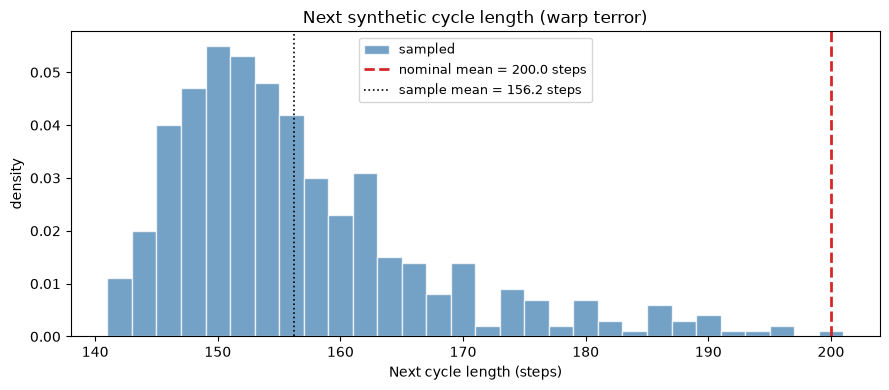

In [10]:
from warp_regression import analyze_cycle_lengths, plot_cycle_length_distribution

cyc = analyze_cycle_lengths(
    model=model,
    sine_fit=sine_fit,
    n_calendar=n_train,
    unit="steps",
    n_paths=500,
    seed=7,
)
fig, ax = plt.subplots(figsize=(9, 4))
plot_cycle_length_distribution(cyc, ax=ax, title="Next synthetic cycle length (warp terror)")
print(
    f"Nominal cycle ≈ {cyc.mean_cycle_length:.1f} steps  |  "
    f"sample median = {np.median(cyc.lengths):.1f} steps  |  "
    f"σ_t = {cyc.sigma_t:.3f}"
)
fig.tight_layout()
plt.show()


## Wrapping up

That's the whole method, end to end, on a case where we can grade the model's homework against ground truth:

| Step | What happened |
|------|----------------|
| 1 | Built a sine cycle, warped it with a hidden random walk, added noise, split train/test |
| 2 | Prefit a rough sine wave by phase-aligning to the training data |
| 3 | Trained `WarpParametricModel` jointly on the dual (error + terror) loss |
| 4 | Checked the learned path against the true path, and looked at how fast train-window uncertainty grows |
| 5 | Forecast the holdout with terror + combined 95% bands from sampled warp paths |
| 6 | Turned the same path samples into a distribution over the next cycle length |

The synthetic case is deliberately clean: one sine, one hidden warp, known ground truth. Next up: the same machinery on real data. **Lynx** trappings (two sine cycles, a shared warp, a century of noisy annual counts) and **Bitcoin** (a single macro cycle riding on top of a strong trend). Same core idea both times, just messier data and more moving parts in the output function.
